In [2]:
!uv pip install matplotlib

Using Python 3.10.20 environment at: /Users/kbshal/mero_space/sarathi_academy/.venv
Checked 1 package in 18ms


In [61]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt

X = load_iris(as_frame=True).data          # 4 features, NO labels

# ALWAYS scale before k-means - it measures distance
X_scaled = StandardScaler().fit_transform(X)

# # n_clusters = groups to find; n_init = restarts (avoid bad luck)
# km = KMeans(n_clusters=3, n_init=10, random_state=42)
# labels = km.fit_predict(X_scaled)         # each row → 0, 1 or 2
# print(km.inertia_)                        # 139.8

In [62]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [63]:
X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/kbshal/mero_space/sarathi_academy/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


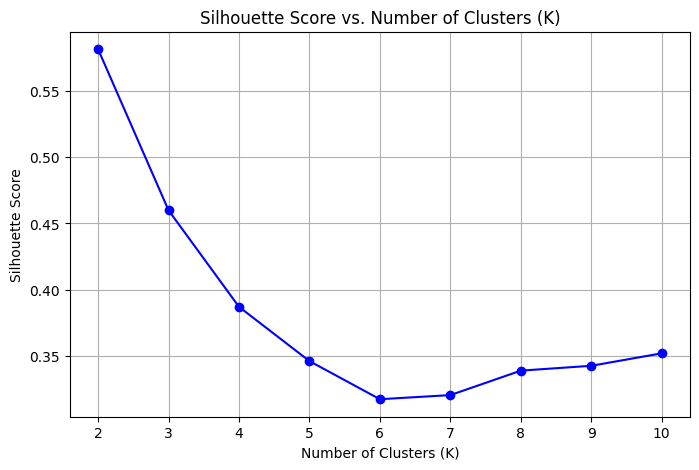

In [71]:
k_values = range(2, 11) # We test K from 2 to 10 (Silhouette needs at least 2 clusters)
silhouette_scores = []

# 3. Run a loop to test each K
for k in k_values:
    # Build the model
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    
    
    # Calculate the Silhouette Score and save it
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    
    
    

# 4. Plot the results
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='b')
plt.title('Silhouette Score vs. Number of Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [65]:
labels

array([6, 2, 2, 2, 6, 0, 6, 6, 2, 2, 0, 6, 2, 2, 0, 0, 0, 6, 0, 0, 6, 0,
       6, 6, 6, 2, 6, 6, 6, 2, 2, 6, 0, 0, 2, 6, 6, 6, 2, 6, 6, 2, 2, 6,
       0, 2, 0, 2, 0, 6, 1, 1, 1, 4, 1, 9, 1, 4, 1, 9, 4, 9, 4, 9, 9, 1,
       9, 9, 4, 4, 1, 9, 8, 9, 1, 1, 1, 1, 9, 4, 4, 4, 9, 8, 9, 1, 1, 4,
       9, 4, 4, 1, 4, 4, 9, 9, 9, 9, 4, 9, 3, 8, 5, 8, 3, 5, 4, 5, 8, 7,
       3, 8, 3, 8, 8, 3, 3, 7, 5, 4, 3, 8, 5, 8, 3, 5, 8, 8, 8, 5, 5, 7,
       8, 8, 8, 5, 3, 3, 8, 3, 3, 3, 8, 3, 3, 3, 8, 3, 3, 8], dtype=int32)

In [73]:

# Build the model
km = KMeans(n_clusters=3, n_init=10, random_state=42)
labels = km.fit_predict(X_scaled)

# Calculate the Silhouette Score and save it
score = silhouette_score(X_scaled, labels)
silhouette_scores.append(score)

    

In [74]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [68]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


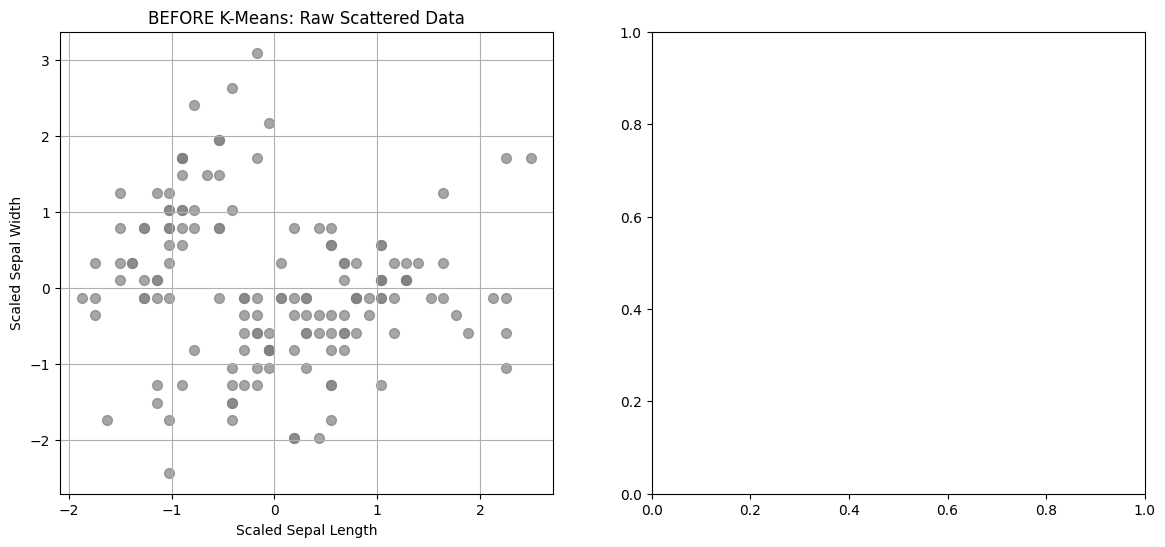

In [75]:
x_data = X_scaled[:, 0]
y_data = X_scaled[:, 1]

# 3. Create a side-by-side canvas (1 row, 2 columns)
# figsize=(14, 6) makes it wide enough to fit both graphs comfortably
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- BEFORE K-MEANS PLOT (Left Side) ---
# We use a single color (gray) because the algorithm hasn't grouped them yet!
ax1.scatter(x_data, y_data, c='gray', s=50, alpha=0.7)
ax1.set_title('BEFORE K-Means: Raw Scattered Data')
ax1.set_xlabel('Scaled Sepal Length')
ax1.set_ylabel('Scaled Sepal Width')
ax1.grid(True)

In [76]:
km.cluster_centers_

array([[-0.05021989, -0.88337647,  0.34773781,  0.2815273 ],
       [-1.01457897,  0.85326268, -1.30498732, -1.25489349],
       [ 1.13597027,  0.08842168,  0.99615451,  1.01752612]])

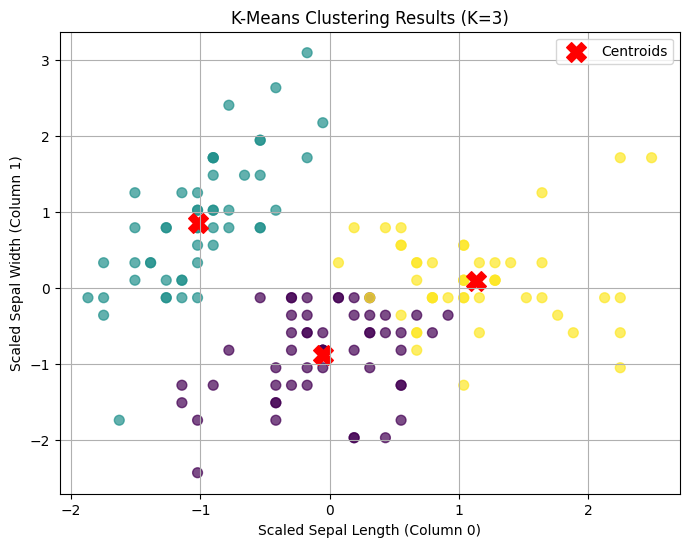

In [78]:
# The [:, 0] syntax means "give me all the rows, but only column 0"
x_axis_data = X_scaled[:, 0] 
y_axis_data = X_scaled[:, 1]

# 2. Set up the canvas size
plt.figure(figsize=(8, 6))

# 3. Plot the data points
# THE MAGIC TRICK: c=labels tells matplotlib to color each dot based on its group number
plt.scatter(x_axis_data, y_axis_data, c=labels, cmap='viridis', s=50, alpha=0.7)

# 4. Plot the Centroids (the center pins)
# km.cluster_centers_ contains the exact coordinates of your final centroids
centroids_x = km.cluster_centers_[:, 0]
centroids_y = km.cluster_centers_[:, 1]

# We use a giant red 'X' so the centroids stand out from the data points
plt.scatter(centroids_x, centroids_y, c='red', s=200, marker='X', label='Centroids')

# 5. Make it look nice and display it
plt.title('K-Means Clustering Results (K=3)')
plt.xlabel('Scaled Sepal Length (Column 0)')
plt.ylabel('Scaled Sepal Width (Column 1)')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [46]:
km.cluster_centers_

array([[-0.05021989, -0.88337647,  0.34773781,  0.2815273 ],
       [-1.01457897,  0.85326268, -1.30498732, -1.25489349],
       [ 1.13597027,  0.08842168,  0.99615451,  1.01752612]])

In [48]:
centroids_x = km.cluster_centers_[:, 0]
centroids_x

array([-0.05021989, -1.01457897,  1.13597027])

In [49]:
centroids_y = km.cluster_centers_[:, 1]

centroids_y

array([-0.88337647,  0.85326268,  0.08842168])

In [50]:
type(labels)

numpy.ndarray